# Parametric (Univariate) Approach Inference
This notebook includes code for loading and doing inference with the parametric generator.
It includes:
- Loading the model and its components.
- Generating training and validation plots
- Generating a grid of edited images
- Sanity Checks
- Diversity Comparisons for FiLM
- Model Export
- Finetuning Plot

# Setup and Loading

## Dependencies

In [ ]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms
import math
from math import isnan
import torch
import torch.nn.functional as F
from collections import defaultdict
import numpy as np
import seaborn as sns


try:
    from scipy.interpolate import CubicSpline
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

from torch.utils.data import DataLoader
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions

%config InlineBackend.figure_format = 'svg'
device = torch.device('cuda')

# This block loads required dependencies
# We then load the cuda environment

print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

Device Info
Selected device: cuda
CUDA available: True
CUDA version: 12.6
GPU count: 8
Current GPU index: 0
GPU name: Tesla P100-SXM2-16GB
GPU capability: (6, 0)


## Validation Dataset

In [30]:
# This cell sets up the coco dataloader of Gebhardt et. al.
# For the parametric generator the image resolution should be greater than 224.
# Which is the trained resolution of the mobilenet backbone
# The model itself does a seperate downscaling.
# The model returns altered images during training. These image resolutions remain original

dataset_input_size = 480
dataset_crop_size = 480
dataset_batch_size = 16 # This is relevant for training. See training code. Here at inference its not important.
dataset_shuffle = False


data_transforms = transforms.Compose([
    transforms.Resize(dataset_input_size),
    transforms.CenterCrop(dataset_crop_size),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), We do not normalize,
    # this way we can apply the global transformations to the original images.
    # The backbone path within the model and the regressor during training handle normalization individually
])

dataset_coco = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = DataLoader(
    dataset_coco,
    batch_size=dataset_batch_size,
    shuffle=dataset_shuffle,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Dataset length:", len(dataset_coco))
print("Batch size:", data_loader.batch_size)
print("Shuffle:", dataset_shuffle)
print("Num workers:", data_loader.num_workers)
print("Number of batches per epoch:", len(data_loader))

dataset_coco[0]

Dataset length: 5000
Batch size: 16
Shuffle: False
Num workers: 4
Number of batches per epoch: 313


(tensor([[[0.3294, 0.3176, 0.3137,  ..., 0.9961, 1.0000, 0.8078],
          [0.2784, 0.2784, 0.2863,  ..., 0.9961, 1.0000, 0.8235],
          [0.1765, 0.1882, 0.2039,  ..., 1.0000, 0.9882, 0.8510],
          ...,
          [0.4157, 0.4980, 0.4275,  ..., 0.5333, 0.5216, 0.4471],
          [0.3137, 0.4510, 0.3882,  ..., 0.3569, 0.4784, 0.4745],
          [0.1804, 0.3216, 0.3490,  ..., 0.3451, 0.3451, 0.4314]],
 
         [[0.3608, 0.3490, 0.3451,  ..., 0.9882, 0.9882, 0.7922],
          [0.3059, 0.3020, 0.3098,  ..., 0.9882, 0.9843, 0.8078],
          [0.1882, 0.2000, 0.2157,  ..., 0.9922, 0.9686, 0.8275],
          ...,
          [0.4196, 0.5020, 0.4314,  ..., 0.5333, 0.5412, 0.4706],
          [0.3255, 0.4627, 0.4039,  ..., 0.3647, 0.5176, 0.5176],
          [0.2000, 0.3412, 0.3686,  ..., 0.3647, 0.3922, 0.4824]],
 
         [[0.4118, 0.4000, 0.3961,  ..., 0.9922, 0.9922, 0.7961],
          [0.3451, 0.3490, 0.3569,  ..., 0.9922, 0.9882, 0.8118],
          [0.2078, 0.2275, 0.2431,  ...,

## Affect Regressor

In [31]:
from social_media_overlay.models.regressor import EmotionRegressor

path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(
    path_to_regressor_model,
    average=False,
    normalize=True, # Model takes in unnormalized images!
)
regressor.to(device)

regressor.eval()
for p in regressor.model.parameters():
    p.requires_grad = False

## Parametric Generator Loading

In [ ]:
# Depending on the type load the specific class:
# 1) The first version is: from social_media_overlay.models.parametric import ConditionalParametricGenerator
# This is the initial formulation without FiLM, FC in Head, Residual in Head, CLIP.
# 2) The second version with a refactored formulation can be found: from social_media_overlay.models.parametric import ConditionalParametricGenerator
# 3) The third refactored version with residual formulation can be found under from social_media_overlay.models.parametric import ConditionalParametricResidualGenerator
# The final version is under: from social_media_overlay.models.parametric_refactor import ConditionalParametricResidualMobileNetGenerator

from social_media_overlay.models.parametric import ConditionalParametricResidualMobileNetGenerator
#from social_media_overlay.models.parametric import ConditionalParametricGenerator
#from social_media_overlay.models.parametric import ConditionalParametricResidualGenerator
from timm.data import resolve_model_data_config

# Load the specific checkpoint file.
directory = "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1/"
path_name = directory+"chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1-final.pt"

checkpoint = torch.load(path_name)

# Initialize the model. This must correspond to the architecture and configuration.
# Information can be found from within the name.

model = ConditionalParametricResidualMobileNetGenerator(
    fc_dim=64,
    fc_depth=3,
    mobilenet_pretrained=True,
    freeze_backbone=True,
    color_head_depth=2,
    color_head_dim=64,
    tone_head_depth=2,
    tone_head_dim=64,
    use_film=False,
    use_res_head=False,
    use_alpha_head=False,
    use_sigmoid_head=True,
).to(device)

#model = ConditionalParametricGenerator(
#    num_features=32,
#    fc_dim=128,
#).to(device)

#model = ConditionalParametricResidualGenerator(
#    num_features=32,
#    fc_dim=128,
#).to(device)


model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

### Backbone Dimensions

In [ ]:
# This prints the expected dimensions of the backbone input
print("backbone_input_hw:", model.backbone_input_hw)
print("backbone_mean:", model.backbone_mean.flatten())
print("backbone_std:", model.backbone_std.flatten())
print("timm data config:", resolve_model_data_config(model.backbone))

backbone_input_hw: (224, 224)
backbone_mean: tensor([0.4850, 0.4560, 0.4060], device='cuda:0')
backbone_std: tensor([0.2290, 0.2240, 0.2250], device='cuda:0')
timm data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}


### Model Layer Output

In [ ]:
# This prints the layers of the model

print(model)

ConditionalParametricResidualMobileNetGenerator(
  (backbone): MobileNetV3(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): ConvBnAct(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (aa): Identity()
          (drop_path): Identity()
        )
        (1): ConvBnAct(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop)

### Output Backbone Informations

In [ ]:
# This prints the backbone version
print(type(model.backbone))
print(model.backbone.default_cfg.get("architecture"))
print(model.backbone.pretrained_cfg.get("architecture"))

<class 'timm.models.mobilenetv3.MobileNetV3'>
mobilenetv4_conv_small
mobilenetv4_conv_small


### Output Model Capacity

In [8]:
# This prints the capacity of the model

def count_params(module):
    return sum(p.numel() for p in module.parameters())

def print_params(model, name):
    module = getattr(model, name, None)
    if module is not None:
        print(f"{name:<16}", count_params(module))
    else:
        print(f"{name:<16}", "not available")

print_params(model, "backbone")
print_params(model, "cond_encoder")
print_params(model, "input_proj")    # only if present
print_params(model, "film_blocks")   # only if present
print_params(model, "param_heads")

print(f"{'full model':<16}", count_params(model))

backbone         2493024
cond_encoder     1120
input_proj       not available
film_blocks      not available
param_heads      10725
full model       2576741


In [ ]:
# This prints the frozen and unfrozen layers of the model
# These are decided at the initalization of the model

model.eval()
dummy = torch.randn(1, 3, *model.backbone_input_hw).to(device)
with torch.no_grad():
    feat = model.backbone(dummy)

print("Backbone output shape:", feat.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Frozen params: {total_params - trainable_params:,}")

Backbone output shape: torch.Size([1, 1280, 7, 7])
Total params: 2,576,741
Trainable params: 83,717
Frozen params: 2,493,024


### Output Training information (Epoch, Steps)

In [9]:
# Print the epoch and batch count
print(checkpoint["epoch"])
print(checkpoint["batch"])

24
1848


### Save Training Loss Plot

In [ ]:
# Save the training loss values as figure to the directory
loss_history = checkpoint["loss_history"]
print(f"Loaded {len(loss_history)} loss values")
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.savefig(directory+"train_loss.svg")
#plt.show()
plt.close()

Loaded 46225 loss values


### Save Training Loss Plot with Rolling Avg

In [ ]:
# Prints rolling average training loss to the same directory
loss_history = checkpoint["loss_history"]
print(f"Loaded {len(loss_history)} loss values")

window_size = min(200, len(loss_history)) # change this value for different windows sizes

rolling_avg = np.convolve(
    loss_history,
    np.ones(window_size) / window_size,
    mode="valid"
)

x_avg = range(window_size - 1, len(loss_history))

plt.figure(figsize=(10, 5))
plt.plot(loss_history, alpha=0.3, label="Raw loss")
plt.plot(x_avg, rolling_avg, label=f"Rolling avg ({window_size})", linewidth=2)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.savefig(directory + "train_loss_rolling.svg")
plt.close()

Loaded 46225 loss values


### Save Training Loss Plot per Epoch

In [ ]:
# This calculates the loss per epoch
# The figure is saved to the same directory

loss_history = checkpoint["loss_history"]
print(f"Loaded {len(loss_history)} loss values")

# Settable variables
# These are fixed for COCO validatio set 2017!
batch_size = 64
train_dataset_size = 118287   # COCO 2017 train
drop_last = False             # set True if your training loader used drop_last=True

# Compute steps per epoch from COCO train size
if drop_last:
    steps_per_epoch = train_dataset_size // batch_size
else:
    steps_per_epoch = math.ceil(train_dataset_size / batch_size)

epochs = math.ceil(len(loss_history) / steps_per_epoch)

print(f"Batch size: {batch_size}")
print(f"Train dataset size: {train_dataset_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Inferred epochs: {epochs}")

# Calculate average loss per epoch
epoch_losses = []
epoch_numbers = []

for epoch in range(epochs):
    start_idx = epoch * steps_per_epoch
    end_idx = min((epoch + 1) * steps_per_epoch, len(loss_history))

    epoch_chunk = loss_history[start_idx:end_idx]
    if len(epoch_chunk) > 0:
        epoch_losses.append(np.mean(epoch_chunk))
        epoch_numbers.append(epoch + 1)

print(f"Calculated {len(epoch_losses)} epoch loss values")

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    epoch_numbers,
    epoch_losses,
    marker="o",
    markersize=4,
    linewidth=2,
    label="Average loss per epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss per epoch")

# Reduce number of x-axis ticks
num_ticks = min(10, len(epoch_numbers))
tick_positions = np.linspace(1, len(epoch_numbers), num_ticks, dtype=int)
tick_positions = np.unique(tick_positions)
plt.xticks(tick_positions)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(directory + "train_loss_per_epoch.svg")
plt.close()

Loaded 46225 loss values
Batch size: 64
Train dataset size: 118287
Steps per epoch: 1849
Inferred epochs: 25
Calculated 25 epoch loss values


### Save and Show Validation Loss

Loaded 25 loss values


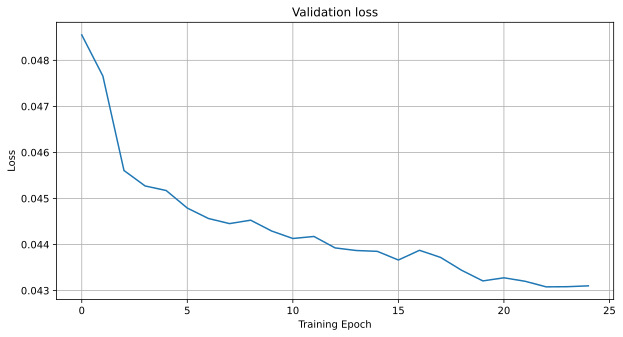

In [ ]:
# Save the validation loss to a figure in the same directory

loss_history = checkpoint["val_loss_history"]

# extract only the 'loss' values
loss_values = [entry["loss"] for entry in loss_history]

print(f"Loaded {len(loss_values)} loss values")

plt.figure(figsize=(10,5))
plt.plot(loss_values)
plt.xlabel("Training Epoch")
plt.ylabel("Loss")
plt.title("Validation loss")
plt.grid(True)
plt.savefig(directory+"val_loss.svg")
plt.show()

### Save and Show Summary Plot of Validation Metrics

Found metrics: ['clip_semantic_loss', 'clipped_target_fraction', 'identity_loss', 'image_l1', 'loss', 'score_abs_error', 'score_loss', 'zero_alpha_image_l1']
clip_semantic_loss: Loaded 25 values
clipped_target_fraction: Loaded 25 values
identity_loss: Loaded 25 values
image_l1: Loaded 25 values
loss: Loaded 25 values
score_abs_error: Loaded 25 values
score_loss: Loaded 25 values
zero_alpha_image_l1: Loaded 25 values


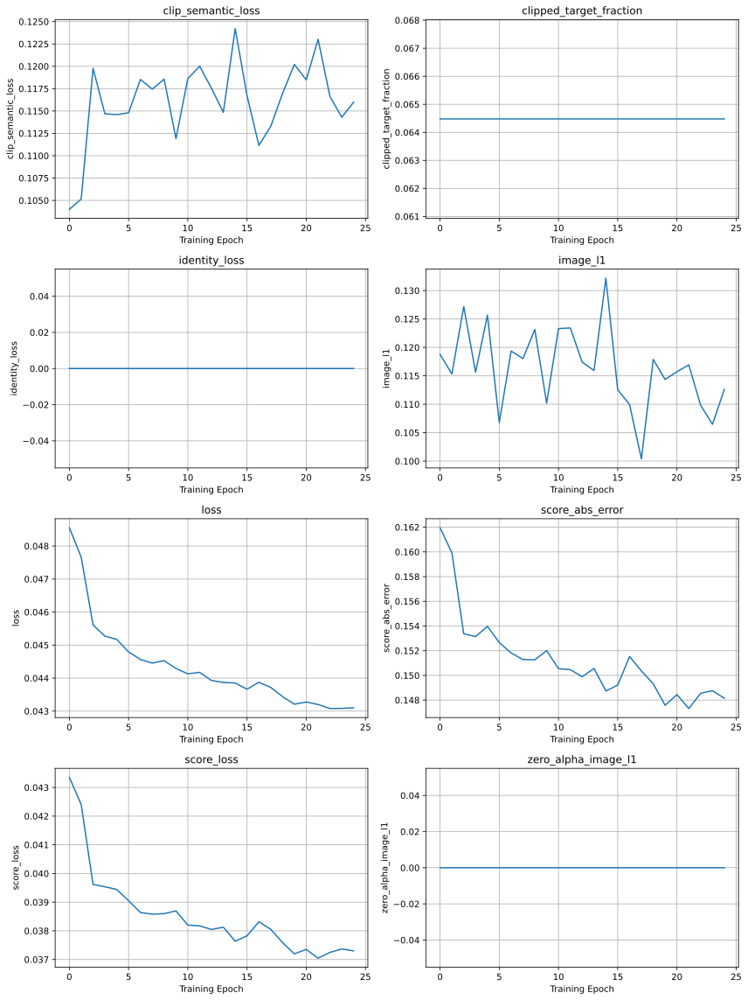

In [ ]:
# Save a summary plot of all validation metrics to the same directory

loss_history = checkpoint["val_loss_history"]

if not loss_history:
    print("val_loss_history is empty.")
else:
    # infer all metric keys dynamically from the history
    metrics = sorted({
        key
        for entry in loss_history
        if isinstance(entry, dict)
        for key in entry.keys()
    })

    print(f"Found metrics: {metrics}")

    num_metrics = len(metrics)

    if num_metrics == 0:
        print("No metrics found in val_loss_history.")
    else:
        cols = 2
        rows = math.ceil(num_metrics / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
        axes = [axes] if num_metrics == 1 else axes.flatten()

        for i, metric in enumerate(metrics):
            values = [
                entry.get(metric, None) if isinstance(entry, dict) else None
                for entry in loss_history
            ]

            axes[i].plot(values)
            axes[i].set_title(metric)
            axes[i].set_xlabel("Training Epoch")
            axes[i].set_ylabel(metric)
            axes[i].grid(True)

            print(f"{metric}: Loaded {sum(v is not None for v in values)} values")

        # hide unused subplot cells
        for j in range(num_metrics, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.savefig(directory + "val_loss_all_metrics.svg")
        plt.show()

# Generate Plot of Image Edits

In [16]:
# This generates a grid of samples
# Rows are samples
# Columns are the samples manipulated by different alphas
# The figure is saved to the same directory

alpha_values = [-0.5, -0.025, -0.01, 0, 0.01, 0.025, 0.5] # Choose values
n = 10

show_param_text = True   # set False to hide the parameter text table, This displays the specific numerical values of the outputs
text_row_ratio = 0.36

def _extract_images(batch):
    if isinstance(batch, torch.Tensor):
        return batch
    if isinstance(batch, (list, tuple)):
        return batch[0]
    if isinstance(batch, dict):
        for k in ["image", "images", "img", "x", "input"]:
            if k in batch:
                return batch[k]
    raise ValueError("Could not extract images from batch.")

def _to_plot(img):
    img = img.detach().cpu().clamp(0, 1)
    if img.shape[0] == 1:
        return img.squeeze(0).numpy(), "gray"
    return img.permute(1, 2, 0).numpy(), None

def _format_params_named(p):
    p = p.detach().cpu()

    exposure   = p[0].item()
    saturation = p[1].item()

    tone = p[2:10]
    color = p[10:34].reshape(3, 8)

    contrast = p[34].item()
    sharp    = p[35].item()
    blur     = p[36].item()

    lines = []
    lines.append(f"exp:{exposure:.2f} sat:{saturation:.2f}")
    lines.append(f"cont:{contrast:.2f} sharp:{sharp:.2f} blur:{blur:.2f}")
    lines.append("tone: " + " ".join(f"{v:.2f}" for v in tone))

    for c_idx, name in enumerate(["R", "G", "B"]):
        lines.append(f"{name}: " + " ".join(f"{v:.2f}" for v in color[c_idx]))

    return "\n".join(lines)

def _set_safe_title(ax, text, fontsize=8, pad=3):
    t = ax.set_title(text, fontsize=fontsize, pad=pad)
    t.set_clip_on(False)
    return t

model.eval()

batch = next(iter(data_loader))
images = _extract_images(batch)[:n].to(device)
n = images.shape[0]

num_cols = len(alpha_values) + 1

if show_param_text:
    fig_width_per_col = 2.4
    fig_height_per_sample = 2.6
    title_fontsize = 8.5
    title_pad = 2.0
    wspace = 0.005
    hspace = 0.05

    total_rows = 2 * n
    height_ratios = []
    for _ in range(n):
        height_ratios.extend([1.0, text_row_ratio])

    fig, axes = plt.subplots(
        total_rows,
        num_cols,
        figsize=(fig_width_per_col * num_cols, fig_height_per_sample * n),
        gridspec_kw={"height_ratios": height_ratios}
    )
else:
    fig_width_per_col = 2.7
    fig_height_per_sample = 2.35
    title_fontsize = 7.5
    title_pad = 4.0
    wspace = 0.04
    hspace = 0.08

    total_rows = n
    fig, axes = plt.subplots(
        total_rows,
        num_cols,
        figsize=(fig_width_per_col * num_cols, fig_height_per_sample * n)
    )

if total_rows == 1:
    axes = axes[None, :]

with torch.no_grad():
    for i in range(n):
        if show_param_text:
            img_row = 2 * i
            txt_row = 2 * i + 1
        else:
            img_row = i

        img = images[i:i+1]

        # original
        orig_pred = regressor.predict(img)
        v0 = orig_pred[0, 0].item()
        a0 = orig_pred[0, 1].item()

        plot_img, cmap = _to_plot(img[0])
        ax = axes[img_row, 0]
        ax.imshow(plot_img, cmap=cmap)
        _set_safe_title(
            ax,
            f"orig\nV={v0:.2f}, A={a0:.2f}",
            fontsize=title_fontsize,
            pad=title_pad
        )
        ax.axis("off")

        if show_param_text:
            txt_ax = axes[txt_row, 0]
            txt_ax.axis("off")
            txt_ax.text(
                0.5, 1.0,
                "original image",
                ha="center", va="top",
                fontsize=6
            )

        # generated
        img_rep = img.repeat(len(alpha_values), 1, 1, 1)
        alphas = torch.tensor(alpha_values, dtype=torch.float32, device=device)

        gen_imgs, flat_params = model(img_rep, alphas)

        preds = regressor.predict(gen_imgs)
        valence = preds[:, 0]
        arousal = preds[:, 1]

        for j, alpha in enumerate(alpha_values):
            ax = axes[img_row, j + 1]

            plot_img, cmap = _to_plot(gen_imgs[j])
            v = valence[j].item()
            a = arousal[j].item()

            ax.imshow(plot_img, cmap=cmap)
            _set_safe_title(
                ax,
                f"a={alpha}\nV={v:.2f}, A={a:.2f}",
                fontsize=title_fontsize,
                pad=title_pad
            )
            ax.axis("off")

            if show_param_text:
                txt_ax = axes[txt_row, j + 1]
                txt_ax.axis("off")
                txt_ax.text(
                    0.5, 1.0,
                    _format_params_named(flat_params[j]),
                    ha="center", va="top",
                    fontsize=5.2,
                    family="monospace",
                    linespacing=0.82
                )

plt.subplots_adjust(
    hspace=hspace,
    wspace=wspace,
    bottom=0.02,
    top=0.98
)

plt.savefig(directory + "samples.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

### Affect Stats

In [25]:
from social_media_overlay.utils import to_tensor
from torch import Tensor
from typing import Any
def get_images_from_batch(batch: Any) -> Tensor:
    if isinstance(batch, Tensor):
        return batch

    if isinstance(batch, (tuple, list)) and len(batch) > 0 and isinstance(batch[0], Tensor):
        return batch[0]

    raise TypeError(
        "Expected each batch to be a Tensor or a tuple/list whose first element is a Tensor."
    )
    
model.eval()

batch = next(iter(data_loader))
images = get_images_from_batch(batch)[:16].to(device)

for alpha in [-0.1, 0.1]:
    with torch.no_grad():
        alphas = torch.full((images.size(0),), alpha, device=device)
        out = model(images, alphas)
        transformed = out[0] if isinstance(out, tuple) else out

        orig_pred = regressor.predict(images)
        trans_pred = regressor.predict(transformed)

        orig_pred = to_tensor(orig_pred, device, images.dtype)
        trans_pred = to_tensor(trans_pred, device, images.dtype)

        dv = (trans_pred[:, 0] - orig_pred[:, 0]).mean().item()
        da = (trans_pred[:, 1] - orig_pred[:, 1]).mean().item()
        l1 = (transformed - images).abs().mean().item()

        print(alpha, "mean ΔV =", dv, "mean ΔA =", da, "L1 =", l1)

-0.1 mean ΔV = -0.03981892764568329 mean ΔA = -0.032792940735816956 L1 = 0.048576146364212036
0.1 mean ΔV = 0.03798065334558487 mean ΔA = 0.052004747092723846 L1 = 0.05570908263325691


# Generate Image Edit Plot
- Generate n seperate figures to target directory
- Each figure shows the evolution of the output values and curves

In [ ]:
# This generates n figures
# For each figure we apply i manipulations by i different alphas
# Each figure shows the evolution of the output values and curves
# At the top each manipulated output image is shown
# The figure is saved to the same directory

# evenly spaced alphas
alpha_values = torch.linspace(-0.2, 0.2, steps=15).tolist() # Here the spacing of alphas can be choosen
n_images = 10 # the amount of figures to generate / the amount of samples to draw

def _extract_images(batch):
    if isinstance(batch, torch.Tensor):
        return batch
    if isinstance(batch, (list, tuple)):
        return batch[0]
    if isinstance(batch, dict):
        for k in ["image", "images", "img", "x", "input"]:
            if k in batch:
                return batch[k]
    raise ValueError("Could not extract images from batch.")

def _to_plot(img):
    img = img.detach().cpu().clamp(0, 1)
    if img.shape[0] == 1:
        return img.squeeze(0).numpy(), "gray"
    return img.permute(1, 2, 0).numpy(), None

def _set_safe_title(ax, text, fontsize=8, pad=3):
    t = ax.set_title(text, fontsize=fontsize, pad=pad)
    t.set_clip_on(False)
    return t

def _extract_named_params(p):
    p = p.detach().cpu()
    exposure   = p[0].item()
    saturation = p[1].item()
    tone       = p[2:10].numpy()                 # 8 values
    color      = p[10:34].reshape(3, 8).numpy() # 3 x 8
    contrast   = p[34].item()
    sharp      = p[35].item()
    blur       = p[36].item()
    return {
        "exposure": exposure,
        "saturation": saturation,
        "tone": tone,
        "color": color,
        "contrast": contrast,
        "sharp": sharp,
        "blur": blur,
    }

def _smooth_curve(y, num=200):
    x = np.arange(len(y), dtype=np.float32)
    x_dense = np.linspace(x.min(), x.max(), num=num)

    if HAS_SCIPY and len(y) >= 4:
        spline = CubicSpline(x, y, bc_type="natural")
        y_dense = spline(x_dense)
    else:
        y_dense = np.interp(x_dense, x, y)

    return x, x_dense, y_dense

model.eval()

batch = next(iter(data_loader))
images = _extract_images(batch).to(device)

n_images = min(n_images, images.shape[0])
num_cols = len(alpha_values) + 1

os.makedirs(directory, exist_ok=True)

for idx in range(n_images):
    img = images[idx:idx+1]

    fig = plt.figure(figsize=(2.5 * num_cols, 19))
    gs = fig.add_gridspec(
        5, 1,
        height_ratios=[3.8, 1.5, 1.7, 2.8, 3.6],
        hspace=0.5
    )

    # row 1: image evolution
    img_gs = gs[0].subgridspec(1, num_cols, wspace=0.05)
    img_axes = [fig.add_subplot(img_gs[0, j]) for j in range(num_cols)]

    # row 2: valence / arousal
    va_ax = fig.add_subplot(gs[1])

    # row 3: scalar parameter evolution
    scalar_ax = fig.add_subplot(gs[2])

    # row 4: tone evolution
    tone_gs = gs[3].subgridspec(1, len(alpha_values), wspace=0.25)
    tone_axes = [fig.add_subplot(tone_gs[0, j]) for j in range(len(alpha_values))]

    # row 5: RGB evolution
    rgb_gs = gs[4].subgridspec(1, len(alpha_values), wspace=0.25)
    rgb_axes = [fig.add_subplot(rgb_gs[0, j]) for j in range(len(alpha_values))]

    with torch.no_grad():
        # original prediction
        orig_pred = regressor.predict(img)
        v0 = orig_pred[0, 0].item()
        a0 = orig_pred[0, 1].item()

        plot_img, cmap = _to_plot(img[0])
        img_axes[0].imshow(plot_img, cmap=cmap)
        _set_safe_title(
            img_axes[0],
            f"orig\nV={v0:.2f}, A={a0:.2f}",
            fontsize=9,
            pad=3
        )
        img_axes[0].axis("off")

        # generated sequence
        img_rep = img.repeat(len(alpha_values), 1, 1, 1)
        alphas = torch.tensor(alpha_values, dtype=torch.float32, device=device)

        gen_imgs, flat_params = model(img_rep, alphas)
        preds = regressor.predict(gen_imgs)

        valence = preds[:, 0].detach().cpu().numpy()
        arousal = preds[:, 1].detach().cpu().numpy()
        named_params = [_extract_named_params(flat_params[j]) for j in range(len(alpha_values))]

        # generated images
        for j, alpha in enumerate(alpha_values):
            ax = img_axes[j + 1]
            plot_img, cmap = _to_plot(gen_imgs[j])

            ax.imshow(plot_img, cmap=cmap)
            _set_safe_title(
                ax,
                f"a={alpha:.2f}\nV={valence[j]:.2f}, A={arousal[j]:.2f}",
                fontsize=9,
                pad=3
            )
            ax.axis("off")

    # valence / arousal evolution
    va_ax.plot(alpha_values, valence, marker="o", linewidth=2, label="Valence")
    va_ax.plot(alpha_values, arousal, marker="s", linewidth=2, label="Arousal")
    va_ax.axhline(v0, linestyle="--", linewidth=1, alpha=0.7)
    va_ax.axhline(a0, linestyle="--", linewidth=1, alpha=0.7)
    va_ax.set_title("Valence and arousal evolution", fontsize=11)
    va_ax.set_xlabel("Alpha")
    va_ax.set_ylabel("Prediction")
    va_ax.grid(True, alpha=0.3)
    va_ax.legend(fontsize=8, ncol=2)

    # scalar parameter evolution
    exposure_vals   = [p["exposure"] for p in named_params]
    saturation_vals = [p["saturation"] for p in named_params]
    contrast_vals   = [p["contrast"] for p in named_params]
    sharp_vals      = [p["sharp"] for p in named_params]
    blur_vals       = [p["blur"] for p in named_params]

    scalar_ax.plot(alpha_values, exposure_vals,   marker="o", linewidth=2, label="Exposure")
    scalar_ax.plot(alpha_values, saturation_vals, marker="o", linewidth=2, label="Saturation")
    scalar_ax.plot(alpha_values, contrast_vals,   marker="o", linewidth=2, label="Contrast")
    scalar_ax.plot(alpha_values, sharp_vals,      marker="o", linewidth=2, label="Sharpness")
    scalar_ax.plot(alpha_values, blur_vals,       marker="o", linewidth=2, label="Blur")

    scalar_ax.set_title("Scalar parameter evolution", fontsize=11)
    scalar_ax.set_xlabel("Alpha")
    scalar_ax.set_ylabel("Parameter value")
    scalar_ax.grid(True, alpha=0.3)
    scalar_ax.legend(fontsize=8, ncol=3)

    # tone evolution with smooth curves
    all_tone = [p["tone"] for p in named_params]
    tone_min = min(t.min() for t in all_tone)
    tone_max = max(t.max() for t in all_tone)

    for j, alpha in enumerate(alpha_values):
        ax = tone_axes[j]
        tone = named_params[j]["tone"]

        x_ctrl, x_dense, y_dense = _smooth_curve(tone, num=200)

        ax.plot(x_dense, y_dense, linewidth=2)
        ax.plot(x_ctrl, tone, marker="o", linestyle="None", markersize=4)

        ax.set_title(f"a={alpha:.2f}", fontsize=9)
        ax.set_xlabel("Tone idx", fontsize=8)
        if j == 0:
            ax.set_ylabel("Value", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, len(tone) - 1)
        ax.set_ylim(tone_min - 0.02, tone_max + 0.02)
        ax.tick_params(labelsize=7)

    tone_axes[0].text(
        0.0, 1.18,
        "Tone curve evolution",
        transform=tone_axes[0].transAxes,
        fontsize=11,
        ha="left",
        va="bottom"
    )

    # RGB evolution with smooth curves
    all_color = [p["color"] for p in named_params]
    color_min = min(c.min() for c in all_color)
    color_max = max(c.max() for c in all_color)

    for j, alpha in enumerate(alpha_values):
        ax = rgb_axes[j]
        color = named_params[j]["color"]

        for c_idx, label in enumerate(["R", "G", "B"]):
            x_ctrl, x_dense, y_dense = _smooth_curve(color[c_idx], num=200)
            ax.plot(x_dense, y_dense, linewidth=1.8, label=label)
            ax.plot(x_ctrl, color[c_idx], marker="o", linestyle="None", markersize=3.5)

        ax.set_title(f"a={alpha:.2f}", fontsize=9)
        ax.set_xlabel("Color idx", fontsize=8)
        if j == 0:
            ax.set_ylabel("Value", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, color.shape[1] - 1)
        ax.set_ylim(color_min - 0.02, color_max + 0.02)
        ax.tick_params(labelsize=7)

    rgb_axes[0].legend(fontsize=7)
    rgb_axes[0].text(
        0.0, 1.18,
        "RGB color curve evolution",
        transform=rgb_axes[0].transAxes,
        fontsize=11,
        ha="left",
        va="bottom"
    )

    plt.savefig(
        os.path.join(directory, f"alpha_evolution_img_{idx}.svg"),
        bbox_inches="tight",
        pad_inches=0.03
    )
    plt.close(fig)

# Output Diversity
This code calculates the required output statistics for diversity comparison
How to:
- Load a model then run the statistics computation
- Then save to new df
- Load the next model and append the results to the df
Finally run the comparison function.

In [ ]:
# This cell calculates numerical output statistics
# It can be used to compare the diversity of edits and outputs
# See usage below!
# We load different models run the calculations on the whole validation set
# and save the results in a dataframe
# We can then compare the rows of the dataframe

# helper code

def _extract_images(batch):
    if isinstance(batch, torch.Tensor):
        images = batch
    elif isinstance(batch, (list, tuple)):
        images = batch[0]
    elif isinstance(batch, dict):
        for k in ["image", "images", "img", "x", "input"]:
            if k in batch:
                images = batch[k]
                break
        else:
            raise ValueError("Could not find images in batch dict")
    else:
        raise ValueError(f"Unknown batch format: {type(batch)}")
    return images


def _offdiag_stats(d):
    if d.size(0) < 2:
        return {"mean": float("nan"), "min": float("nan"), "max": float("nan")}

    mask = ~torch.eye(d.size(0), dtype=torch.bool, device=d.device)
    vals = d[mask]
    return {
        "mean": vals.mean().item(),
        "min": vals.min().item(),
        "max": vals.max().item(),
    }


def _mean_abs_pairwise_diff(x):
    b = x.shape[0]
    if b < 2:
        return float("nan")

    x_flat = x.view(b, -1)
    diffs = []
    for i in range(b):
        for j in range(i + 1, b):
            diffs.append((x_flat[i] - x_flat[j]).abs().mean())
    return torch.stack(diffs).mean().item()


def _feature_std_mean(x):
    x_flat = x.view(x.shape[0], -1)
    if x_flat.shape[0] < 2:
        return float("nan")
    return x_flat.std(dim=0, unbiased=False).mean().item()


class RunningStats:
    def __init__(self):
        self.sum = 0.0
        self.count = 0

    def update(self, value, n=1):
        if value is None:
            return
        if isinstance(value, float) and isnan(value):
            return
        self.sum += float(value) * n
        self.count += n

    @property
    def mean(self):
        return self.sum / max(self.count, 1)


# main evaluation
def evaluate_model_diversity_over_loader(
    model,
    data_loader,
    device,
    alpha_value=0.5,
    regressor=None,
    max_batches=None,
    store_per_sample=False,
):
    model.eval()

    stats = defaultdict(RunningStats)
    per_sample = defaultdict(list) if store_per_sample else None

    total_samples = 0
    total_batches = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            imgs = _extract_images(batch).to(device)
            bsz = imgs.shape[0]

            if bsz < 2:
                print(f"Skipping batch {batch_idx} because batch size < 2")
                continue

            total_batches += 1
            total_samples += bsz

            # =========================
            # 0. INPUT DIVERSITY
            # =========================
            stats["input.feature_std_mean"].update(_feature_std_mean(imgs))
            stats["input.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(imgs))

            imgs_flat = imgs.view(bsz, -1)
            d_in = torch.cdist(imgs_flat, imgs_flat)
            d_in_stats = _offdiag_stats(d_in)
            stats["input.pairwise_dist.mean"].update(d_in_stats["mean"])
            stats["input.pairwise_dist.min"].update(d_in_stats["min"])
            stats["input.pairwise_dist.max"].update(d_in_stats["max"])

            # =========================
            # 1. ENCODER DIVERSITY
            # =========================
            enc = model.get_img_enc(imgs)

            stats["enc.feature_std_mean"].update(_feature_std_mean(enc))
            stats["enc.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(enc))

            d_enc = torch.cdist(enc, enc)
            d_enc_stats = _offdiag_stats(d_enc)
            stats["enc.pairwise_dist.mean"].update(d_enc_stats["mean"])
            stats["enc.pairwise_dist.min"].update(d_enc_stats["min"])
            stats["enc.pairwise_dist.max"].update(d_enc_stats["max"])

            # =========================
            # 2. CONDITIONING
            # =========================
            alpha_fixed = torch.full((bsz,), alpha_value, device=device)
            alpha_in = alpha_fixed.unsqueeze(1)
            cond = model.cond_encoder(alpha_in)

            stats["cond.feature_std_mean"].update(_feature_std_mean(cond))
            stats["cond.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(cond))

            # =========================
            # 3. SHARED LATENT
            # =========================
            if getattr(model, "use_film", False):
                x = F.leaky_relu(model.input_proj(enc))

                stats["latent.input_proj.feature_std_mean"].update(_feature_std_mean(x))
                stats["latent.input_proj.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(x))

                for i, block in enumerate(model.film_blocks):
                    x = block(x, cond)
                    stats[f"latent.film_block_{i}.feature_std_mean"].update(_feature_std_mean(x))
                    stats[f"latent.film_block_{i}.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(x))
            else:
                x = torch.cat([enc, cond], dim=1)

                stats["latent.concat.feature_std_mean"].update(_feature_std_mean(x))
                stats["latent.concat.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(x))

                for i, layer in enumerate(model.fc_layers):
                    x = F.leaky_relu(layer(x))
                    stats[f"latent.fc_layer_{i}.feature_std_mean"].update(_feature_std_mean(x))
                    stats[f"latent.fc_layer_{i}.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(x))

            # =========================
            # 4. RAW HEADS
            # =========================
            for param in ["tone", "color", "exposure", "contrast", "saturation", "sharp", "blur"]:
                if param not in model.param_heads:
                    continue

                raw = model.param_heads[param](x)
                raw_flat = raw.view(raw.shape[0], -1)

                stats[f"raw.{param}.feature_std_mean"].update(_feature_std_mean(raw_flat))
                stats[f"raw.{param}.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(raw_flat))

                if store_per_sample:
                    per_sample[f"raw.{param}"].append(raw_flat.detach().cpu())

            # =========================
            # 5. FINAL PARAMS
            # =========================
            params = model.get_predicted_params(enc, alpha_fixed)

            tone = params["tone"][:, 0, :, 0]
            stats["final.tone.feature_std_mean"].update(_feature_std_mean(tone))
            stats["final.tone.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(tone))
            if store_per_sample:
                per_sample["final.tone"].append(tone.detach().cpu())

            if "color" in params:
                color = params["color"][:, :, :, 0].reshape(params["color"].shape[0], -1)
                stats["final.color.feature_std_mean"].update(_feature_std_mean(color))
                stats["final.color.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(color))
                if store_per_sample:
                    per_sample["final.color"].append(color.detach().cpu())

            for param in ["exposure", "contrast", "saturation", "sharp", "blur"]:
                if param in params:
                    val = params[param]
                    val = val.view(val.shape[0], -1) if val.ndim > 1 else val.unsqueeze(1)

                    stats[f"final.{param}.feature_std_mean"].update(_feature_std_mean(val))
                    stats[f"final.{param}.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(val))
                    if store_per_sample:
                        per_sample[f"final.{param}"].append(val.detach().cpu())

            # =========================
            # 6. MODEL OUTPUT
            # =========================
            out_imgs, flat_params = model(imgs, alpha_fixed)

            stats["output.feature_std_mean"].update(_feature_std_mean(out_imgs))
            stats["output.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(out_imgs))
            stats["flat_params.feature_std_mean"].update(_feature_std_mean(flat_params))
            stats["flat_params.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(flat_params))

            stats["output.mean_abs_change_from_input"].update(
                (out_imgs - imgs[:, :out_imgs.shape[1]]).abs().mean().item()
            )

            pairwise_out = torch.cdist(
                out_imgs.view(out_imgs.shape[0], -1),
                out_imgs.view(out_imgs.shape[0], -1),
            )
            pairwise_out_stats = _offdiag_stats(pairwise_out)
            stats["output.pairwise_dist.mean"].update(pairwise_out_stats["mean"])
            stats["output.pairwise_dist.min"].update(pairwise_out_stats["min"])
            stats["output.pairwise_dist.max"].update(pairwise_out_stats["max"])

            edits = out_imgs - imgs[:, :out_imgs.shape[1]]
            stats["edit.mean_abs_magnitude"].update(edits.abs().mean().item())
            stats["edit.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(edits))

            pairwise_edit = torch.cdist(
                edits.view(edits.shape[0], -1),
                edits.view(edits.shape[0], -1),
            )
            pairwise_edit_stats = _offdiag_stats(pairwise_edit)
            stats["edit.pairwise_dist.mean"].update(pairwise_edit_stats["mean"])
            stats["edit.pairwise_dist.min"].update(pairwise_edit_stats["min"])
            stats["edit.pairwise_dist.max"].update(pairwise_edit_stats["max"])

            # =========================
            # 7. INTERMEDIATE STAGES
            # =========================
            if hasattr(model, "img_list") and model.img_list is not None:
                stats["intermediate.num_stages"].update(len(model.img_list))

                for i, stage_img in enumerate(model.img_list):
                    stats[f"stage_{i}.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(stage_img))
                    stats[f"stage_{i}.mean_abs_change_from_input"].update(
                        (stage_img - imgs[:, :stage_img.shape[1]]).abs().mean().item()
                    )

            # =========================
            # 8. OPTIONAL REGRESSOR
            # =========================
            if regressor is not None:
                try:
                    orig_scores = regressor.predict(imgs)
                    out_scores = regressor.predict(out_imgs)

                    orig_scores_t = torch.as_tensor(orig_scores, device=device)
                    out_scores_t = torch.as_tensor(out_scores, device=device)

                    score_delta = out_scores_t - orig_scores_t

                    stats["regressor.score_delta_mean"].update(score_delta.mean().item())
                    stats["regressor.score_delta_abs_mean"].update(score_delta.abs().mean().item())
                    stats["regressor.orig.feature_std_mean"].update(_feature_std_mean(orig_scores_t))
                    stats["regressor.out.feature_std_mean"].update(_feature_std_mean(out_scores_t))
                    stats["regressor.delta.mean_abs_pairwise_diff"].update(_mean_abs_pairwise_diff(score_delta))

                    if store_per_sample:
                        per_sample["regressor.orig_scores"].append(orig_scores_t.detach().cpu())
                        per_sample["regressor.out_scores"].append(out_scores_t.detach().cpu())

                except Exception as e:
                    print(f"[batch {batch_idx}] Skipping regressor debug due to error: {repr(e)}")

    summary = {
        "num_batches": total_batches,
        "num_samples": total_samples,
        "use_film": bool(getattr(model, "use_film", False)),
    }

    for k, v in stats.items():
        summary[k] = v.mean

    if store_per_sample:
        for k in list(per_sample.keys()):
            per_sample[k] = torch.cat(per_sample[k], dim=0)
        return summary, per_sample

    return summary


# dataframe utilities
def add_model_results_to_df(results_df, model_name, summary_dict):
    """
    Adds one model's summary as one row to a dataframe.
    Index = model_name
    """
    row_df = pd.DataFrame([summary_dict], index=[model_name])

    if results_df is None or len(results_df) == 0:
        results_df = row_df
    else:
        results_df = pd.concat([results_df, row_df], axis=0)

    return results_df


def evaluate_and_add_to_df(
    results_df,
    model,
    model_name,
    data_loader,
    device,
    alpha_value=0.5,
    regressor=None,
    max_batches=None,
):
    summary = evaluate_model_diversity_over_loader(
        model=model,
        data_loader=data_loader,
        device=device,
        alpha_value=alpha_value,
        regressor=regressor,
        max_batches=max_batches,
        store_per_sample=False,
    )
    results_df = add_model_results_to_df(results_df, model_name, summary)
    return results_df


def compare_models(results_df, model_a, model_b, sort_by="abs_diff", ascending=False):
    """
    Returns a comparison dataframe between two rows in results_df.

    Columns:
    - model_a
    - model_b
    - abs_diff = model_a - model_b
    - rel_diff_vs_b = (model_a - model_b) / (abs(model_b) + 1e-12)

    Non-numeric columns are ignored.
    """
    if model_a not in results_df.index:
        raise KeyError(f"{model_a} not found in dataframe index")
    if model_b not in results_df.index:
        raise KeyError(f"{model_b} not found in dataframe index")

    row_a = results_df.loc[model_a]
    row_b = results_df.loc[model_b]

    numeric_cols = []
    for col in results_df.columns:
        try:
            float(row_a[col])
            float(row_b[col])
            numeric_cols.append(col)
        except Exception:
            pass

    a = row_a[numeric_cols].astype(float)
    b = row_b[numeric_cols].astype(float)

    comp = pd.DataFrame({
        model_a: a,
        model_b: b,
    })

    comp["abs_diff"] = comp[model_a] - comp[model_b]
    comp["rel_diff_vs_b"] = comp["abs_diff"] / (comp[model_b].abs() + 1e-12)

    if sort_by is not None:
        comp = comp.sort_values(sort_by, ascending=ascending)

    return comp


def compare_all_models_pairwise(results_df, baseline_model):
    """
    Compares every model row against baseline_model.
    Returns one long dataframe.
    """
    if baseline_model not in results_df.index:
        raise KeyError(f"{baseline_model} not found in dataframe index")

    frames = []
    for other_model in results_df.index:
        if other_model == baseline_model:
            continue

        comp = compare_models(results_df, other_model, baseline_model, sort_by=None)
        comp = comp.reset_index().rename(columns={"index": "metric"})
        comp.insert(0, "compare_model", other_model)
        comp.insert(1, "baseline_model", baseline_model)
        frames.append(comp)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, axis=0, ignore_index=True)


def get_metric_subset(results_df, contains=None, startswith=None):
    """
    Helpful for selecting a subset of columns.
    """
    cols = list(results_df.columns)

    if contains is not None:
        cols = [c for c in cols if contains in c]

    if startswith is not None:
        cols = [c for c in cols if c.startswith(startswith)]

    return results_df[cols].copy()

In [ ]:
# Run only once!
# Create a new dataframe that holds the results
results_df = pd.DataFrame()

In [ ]:
# Calculate statistics of the currently loaded model
# and save it to the df
results_df = evaluate_and_add_to_df(
    results_df=results_df,
    model=model,
    model_name="film", # name for identification
    data_loader=data_loader,
    device=device,
    alpha_value=0.1,
    regressor=regressor if "regressor" in globals() else None,
)

In [ ]:
# Compare the different output and edit differences
comparison_df = compare_models(results_df, "film", "no_film")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)
print(comparison_df)

                                                   film      no_film   abs_diff  rel_diff_vs_b
edit.pairwise_dist.min                        44.599144    29.414082  15.185062   5.162514e-01
edit.pairwise_dist.mean                       82.671140    72.817955   9.853185   1.353126e-01
use_film                                       1.000000     0.000000   1.000000   1.000000e+12
raw.exposure.mean_abs_pairwise_diff            0.193437     0.113987   0.079450   6.970140e-01
raw.exposure.feature_std_mean                  0.164942     0.096828   0.068114   7.034561e-01
final.saturation.mean_abs_pairwise_diff        0.248228     0.193810   0.054418   2.807800e-01
stage_2.mean_abs_change_from_input             0.075077     0.027033   0.048044   1.777266e+00
final.saturation.feature_std_mean              0.210247     0.162929   0.047319   2.904253e-01
final.color.mean_abs_pairwise_diff             0.145981     0.113595   0.032386   2.850977e-01
raw.tone.mean_abs_pairwise_diff                0.0

# Generation Sanity Check
This sanity check applies (no-op) transformations to images then plots source and edited.
The edited images must be the same also the given scoring must be equal. (This depends on the behaviour of the regressor, you must change to crop average)

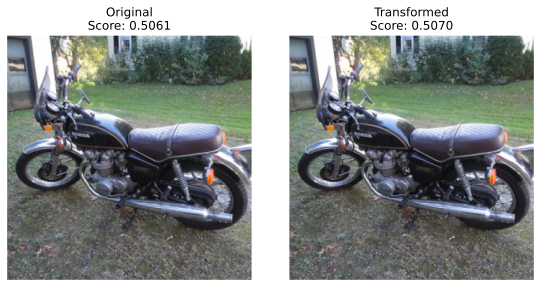

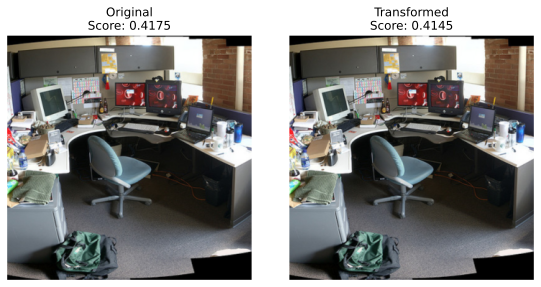

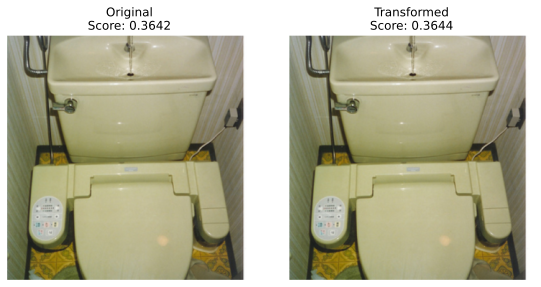

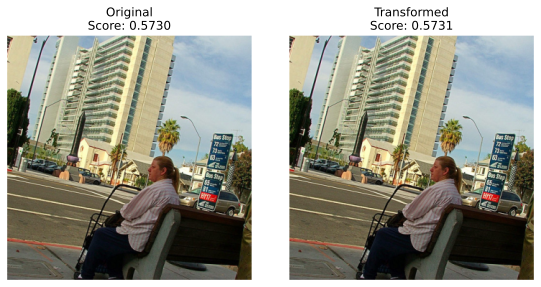

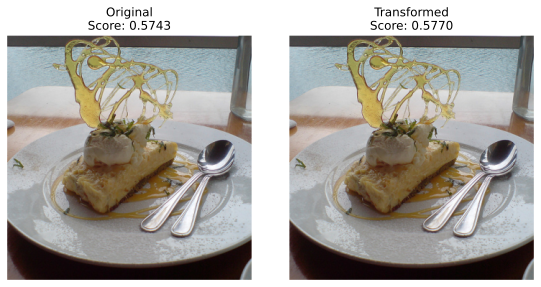

In [ ]:
# This generates manipulated images with alpha 0
# It can be used to compare the original images to the noops qualitatively

def show_identity_images(data_loader, regressor, n_images=5, device=None):
    import torch
    import matplotlib.pyplot as plt
    from social_media_overlay.ext.gebhardt.image_transformations.image_transformations import apply_params

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    regressor = regressor.to(device)
    regressor.eval()

    shown = 0

    with torch.no_grad():
        for batch in data_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)

            for i in range(x.shape[0]):
                img = x[i:i+1, :3]

                params = {
                    "saturation": torch.tensor([1.0], device=device, dtype=img.dtype),
                    "exposure": torch.tensor([0.0], device=device, dtype=img.dtype),
                    "tone": torch.ones(1, 1, 8, 1, device=device, dtype=img.dtype),
                    "color": torch.ones(1, 3, 8, 1, device=device, dtype=img.dtype),
                    "contrast": torch.tensor([1.0], device=device, dtype=img.dtype),
                    "sharp": torch.tensor([1.1], device=device, dtype=img.dtype),
                    "blur": torch.tensor([1e-6], device=device, dtype=img.dtype),
                    # others
                    "gamma": torch.tensor([1.0], device=device, dtype=img.dtype),
                    "wb": torch.tensor([0.0], device=device, dtype=img.dtype),
                    "bright": torch.tensor([0.0], device=device, dtype=img.dtype),
                    "bw": torch.tensor([0.0], device=device, dtype=img.dtype),
                    "hue": torch.tensor([0.0], device=device, dtype=img.dtype),
                }

                y = apply_params(img, params)[-1]

                original_score = regressor.predict(img)[:, :1]
                transformed_score = regressor.predict(y)[:, :1]

                img_np = img[0].detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()
                y_np = y[0].detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()

                plt.figure(figsize=(8, 4))

                plt.subplot(1, 2, 1)
                plt.title(f"Original\nScore: {original_score[0].item():.4f}")
                plt.imshow(img_np)
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.title(f"Transformed\nScore: {transformed_score[0].item():.4f}")
                plt.imshow(y_np)
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= n_images:
                    return


show_identity_images(
    data_loader,
    regressor,
    n_images=5
)

# Model Export
The following code export the loaded model in onnx format
to the directory set in the configuration above.

In [ ]:
# This exports the model agnostic to image resolution

model.eval()

example_inputs = (
    torch.randn(1, 3, 480, 480, device=device),
    torch.tensor([0.5], dtype=torch.float32, device=device)
)

dyn_shapes = {
    "x": {0: "batch", 2: "height", 3: "width"},
    "alpha": {0: "batch"},
}

torch.onnx.export(
    model,
    example_inputs,
    path_name + ".dyn.onnx",
    input_names=["images", "alphas"],
    output_names=["output_images", "transform_params"],
    opset_version=21,
    dynamic_shapes=dyn_shapes,
    dynamo=True,
    report=True,
    verify=True,
    external_data=False, # no separate data file!
)

 # dynamic_axes={
 #       "images": {0: "batch"},
 #       "alphas": {0: "batch"},
 #       "output_images": {0: "batch"},
 #       "transform_params": {0: "batch"},
 #   },

[torch.onnx] Obtain model graph for `ConditionalParametricResidualMobileNetGenerator([...]` with `torch.export.export(..., strict=False)`...


/home/marcel.schubert/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.img_list[0], self.img_list[1], self.img_list[2], self.img_list[3], self.img_list[4], self.img_list[5], self.img_list[6] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `ConditionalParametricResidualMobileNetGenerator([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `ConditionalParametricResidualMobileNetGenerator([...]` with `torch.export.export(..., strict=True)`...


/home/marcel.schubert/data/BA_social_media_overlay/python/.venv/lib/python3.12/site-packages/torch/_dynamo/output_graph.py:2052: UserWarning: While compiling, we found certain side effects happened in the model.forward. Here are the list of potential sources you can double check: ["L['self']._modules['_export_root']"]
  warnings.warn(


[torch.onnx] Obtain model graph for `ConditionalParametricResidualMobileNetGenerator([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decompositions...


/home/marcel.schubert/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 159 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
[torch.onnx] Check the ONNX model...
[torch.onnx] Check the ONNX model... ✅
[torch.onnx] Execute the model with ONNX Runtime...
[torch.onnx] Execute the model with ONNX Runtime... ❌
[torch.onnx] Export report has been saved to 'onnx_export_2026-03-30_18-52-09-018996_runtime.md'.


/home/marcel.schubert/data/BA_social_media_overlay/python/.venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:487: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 21},
            producer_name='pytorch',
            producer_version='2.11.0+cu126',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"images"<FLOAT,[batch,3,height,width]>,
                %"alphas"<FLOAT,[batch]>
            ),
            outputs=(
                %"output_images"<FLOAT,[1,3,height,width]>,
                %"transform_params"<FLOAT,[batch,5*((1//batch)) + ((8//batch)) + ((24//batch))]>
            ),
            initializers=(
                %"backbone.conv_stem.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"backbone.blocks.0.0.conv.weight"<FLOAT,[32,32,3,3]>{Tensor(...)},
                %"backbone.blocks.0.1.conv.weight"<FLOAT,[32,32,1,1]>{Tensor(...)},
                %"backbone.blocks.1.0.conv.weight"<FLOAT,[96,32,3,3]>{Tensor(...)},
                %"backbone

# Image Metrics Sanity Check
This code provides a short sanity check showing that image attribute metrics can be run.

In [4]:
from social_media_overlay.low_level_image_metrics import val_image_properties, summarize_image_property_dicts

all_scores = []

with torch.no_grad():
    for X, _ in data_loader:
        scores = val_image_properties(X)
        all_scores.append(scores)

final_stats = summarize_image_property_dicts(all_scores)
print(final_stats)

{'colorfulness_mean': 12.16887092590332, 'colorfulness_std': 5.4101691246032715, 'mean_brightness_mean': 0.45208486914634705, 'mean_brightness_std': 0.11716418713331223, 'mean_saturation_mean': 0.3176908791065216, 'mean_saturation_std': 0.1599530577659607, 'rms_contrast_mean': 0.23094826936721802, 'rms_contrast_std': 0.055240511894226074, 'lighting_diversity_mean': 23.659435272216797, 'lighting_diversity_std': 5.586483955383301, 'blur_effect_mean': 0.023411007598042488, 'blur_effect_std': 0.030489198863506317, 'num_samples': 5000}


# Finetuning
This section includes the comparison plot after the finetuning stage.
## Comparison of Valiation Metrics

Found metrics across all models: ['clip_semantic_loss', 'clipped_target_fraction', 'identity_loss', 'image_l1', 'loss', 'score_abs_error', 'score_loss', 'zero_alpha_image_l1']


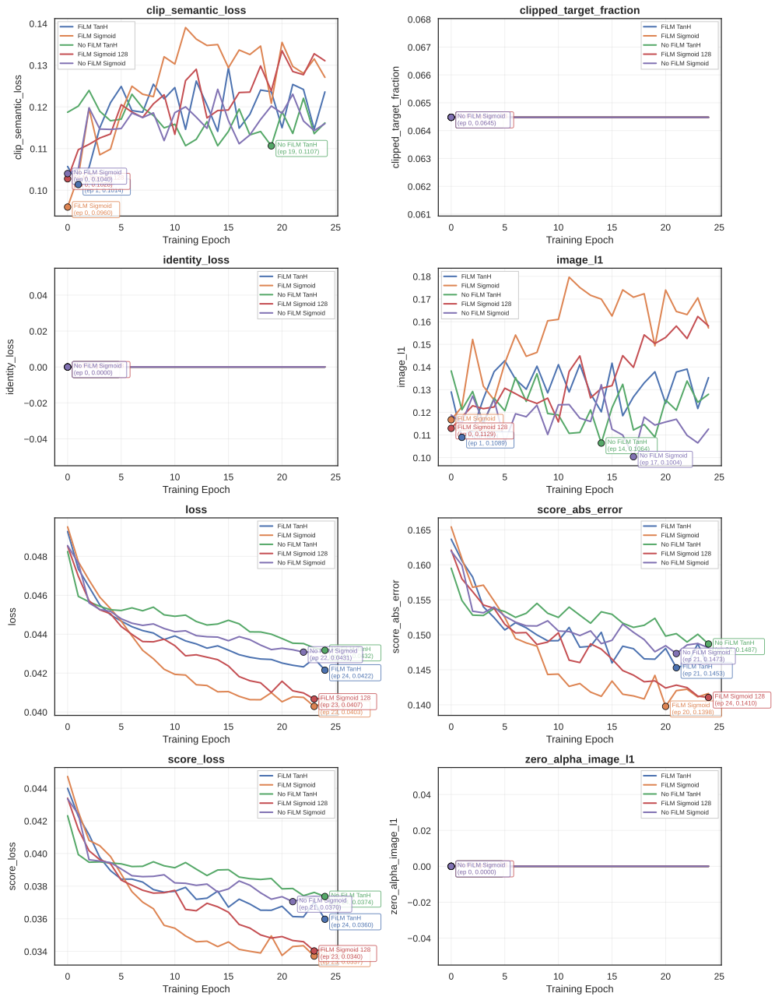


Saved comparison plot to: ../data/models/val_loss_comparison_all_metrics.svg

BEST VALIDATION VALUES PER METRIC, SORTED BY LOWEST VALUE

Metric: clip_semantic_loss
   1. FiLM Sigmoid              epoch=0    value=0.095972
   2. FiLM TanH                 epoch=1    value=0.101385
   3. FiLM Sigmoid 128          epoch=0    value=0.102757
   4. No FiLM Sigmoid           epoch=0    value=0.104003
   5. No FiLM TanH              epoch=19   value=0.110652

Metric: clipped_target_fraction
   1. FiLM TanH                 epoch=0    value=0.064478
   2. FiLM Sigmoid              epoch=0    value=0.064478
   3. No FiLM TanH              epoch=0    value=0.064478
   4. FiLM Sigmoid 128          epoch=0    value=0.064478
   5. No FiLM Sigmoid           epoch=0    value=0.064478

Metric: identity_loss
   1. FiLM TanH                 epoch=0    value=0.000000
   2. FiLM Sigmoid              epoch=0    value=0.000000
   3. No FiLM TanH              epoch=0    value=0.000000
   4. FiLM Sigmoid 128   

In [48]:
# Give each checkpoint a custom short name
pt_files = [
    {
        "path": "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2_lr1e-4_1-2/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2_lr1e-4_1-2-final.pt",
        "name": "FiLM TanH"
    },
    {
        "path": "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1-final.pt",
        "name": "FiLM Sigmoid"
    },
    {
        "path": "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2_lr1e-4_1-1/chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2_lr1e-4_1-1-final.pt",
        "name": "No FiLM TanH"
    },
    {
        "path": "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc128-3_headfc64-2-sig_lr1e-4_1-1/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc128-3_headfc64-2-sig_lr1e-4_1-1-final.pt",
        "name": "FiLM Sigmoid 128"
    },
        {
        "path": "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1/chkp_param_raw_ref_arous_il0_clip5e-2_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1-final.pt",
        "name": "No FiLM Sigmoid"
    },
]
    #{
    #    "path": "../data/models/",
    #    "name": "Baseline Alpha Head"
    #},

save_path = "../data/models/val_loss_comparison_all_metrics.svg"

# HELPERS
def make_model_label(path):
    return os.path.splitext(os.path.basename(path))[0]


def load_val_loss_history(pt_path):
    checkpoint = torch.load(pt_path, map_location="cpu")

    if "val_loss_history" not in checkpoint:
        print(f"[WARNING] No 'val_loss_history' in {pt_path}")
        return None

    loss_history = checkpoint["val_loss_history"]

    if not loss_history:
        print(f"[WARNING] val_loss_history is empty in {pt_path}")
        return None

    return loss_history


def extract_metrics(loss_history):
    return sorted({
        key
        for entry in loss_history
        if isinstance(entry, dict)
        for key in entry.keys()
    })


def extract_metric_values(loss_history, metric):
    values = []
    for entry in loss_history:
        if isinstance(entry, dict):
            v = entry.get(metric, None)
            if isinstance(v, torch.Tensor):
                v = v.item()
            values.append(v)
        else:
            values.append(None)
    return values


def find_best(values):
    valid = [(i, v) for i, v in enumerate(values) if v is not None]
    if not valid:
        return None, None
    best_epoch, best_value = min(valid, key=lambda x: x[1])
    return best_epoch, best_value



# LOAD ALL MODEL VALIDATION DATA FROM THE CHECKPOINT
all_models = []

for entry in pt_files:
    pt_path = entry["path"]
    model_label = entry.get("name", make_model_label(pt_path))

    loss_history = load_val_loss_history(pt_path)
    if loss_history is None:
        continue

    metrics = extract_metrics(loss_history)

    all_models.append({
        "path": pt_path,
        "label": model_label,
        "loss_history": loss_history,
        "metrics": metrics,
    })

if not all_models:
    raise ValueError("No valid checkpoints with non-empty val_loss_history were loaded.")


# union of all metrics across all models
all_metrics = sorted({
    metric
    for model in all_models
    for metric in model["metrics"]
})

print(f"Found metrics across all models: {all_metrics}")

if not all_metrics:
    raise ValueError("No metrics found in val_loss_history across the provided checkpoints.")



# Plotting Code
num_metrics = len(all_metrics)
cols = 2
rows = math.ceil(num_metrics / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
axes = [axes] if num_metrics == 1 else axes.flatten()

# stores ranking info for printing later
summary = {metric: [] for metric in all_metrics}

for i, metric in enumerate(all_metrics):
    ax = axes[i]

    for model in all_models:
        values = extract_metric_values(model["loss_history"], metric)

        if not any(v is not None for v in values):
            continue

        line, = ax.plot(values, label=model["label"], linewidth=2)

        best_epoch, best_value = find_best(values)
        if best_epoch is not None:
            ax.scatter(
                best_epoch,
                best_value,
                color=line.get_color(),
                s=70,
                edgecolors="black",
                linewidths=0.8,
                zorder=4,
            )

            ax.annotate(
                f"{model['label']}\n(ep {best_epoch}, {best_value:.4f})",
                xy=(best_epoch, best_value),
                xytext=(8, -10),
                textcoords="offset points",
                fontsize=8,
                color=line.get_color(),
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec=line.get_color(),
                    alpha=0.8
                ),
            )

            summary[metric].append({
                "model": model["label"],
                "epoch": best_epoch,
                "value": best_value,
            })

    ax.set_title(metric)
    ax.set_xlabel("Training Epoch")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

# hide unused subplot cells
for j in range(num_metrics, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(save_path, bbox_inches="tight")
plt.show()

print(f"\nSaved comparison plot to: {save_path}")


# PRINT SORTED SUMMARY
print("\n" + "=" * 90)
print("BEST VALIDATION VALUES PER METRIC, SORTED BY LOWEST VALUE")
print("=" * 90)

for metric in all_metrics:
    print(f"\nMetric: {metric}")

    ranked = sorted(summary[metric], key=lambda x: x["value"])

    if not ranked:
        print("  No valid values found.")
        continue

    for rank, item in enumerate(ranked, start=1):
        print(
            f"  {rank:>2}. {item['model']:<25} "
            f"epoch={item['epoch']:<4} value={item['value']:.6f}"
        )

### Final Comparison Plots

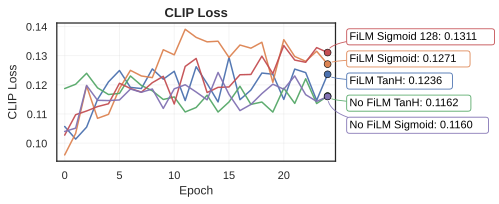

Saved CLIP Loss plot to: ../data/models/individual_metric_plots/clip_loss.svg


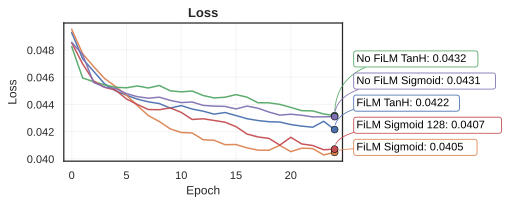

Saved Loss plot to: ../data/models/individual_metric_plots/loss.svg


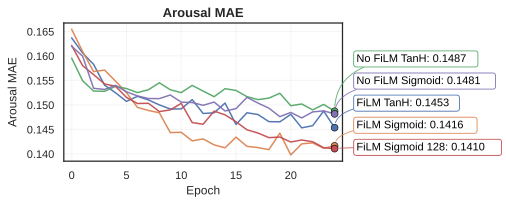

Saved Arousal MAE plot to: ../data/models/individual_metric_plots/arousal_mae.svg


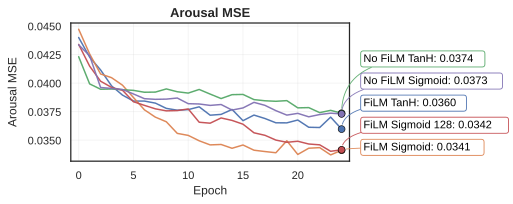

Saved Arousal MSE plot to: ../data/models/individual_metric_plots/arousal_mse.svg

SUMMARY OF MARKED VALUES

Metric: CLIP Loss
   1. No FiLM Sigmoid           last epoch=24   value=0.115988
   2. No FiLM TanH              last epoch=24   value=0.116155
   3. FiLM TanH                 last epoch=24   value=0.123590
   4. FiLM Sigmoid              last epoch=24   value=0.127081
   5. FiLM Sigmoid 128          last epoch=24   value=0.131057

Metric: Loss
   1. FiLM Sigmoid              last epoch=24   value=0.040472
   2. FiLM Sigmoid 128          last epoch=24   value=0.040711
   3. FiLM TanH                 last epoch=24   value=0.042150
   4. No FiLM Sigmoid           last epoch=24   value=0.043101
   5. No FiLM TanH              last epoch=24   value=0.043172

Metric: Arousal MAE
   1. FiLM Sigmoid 128          last epoch=24   value=0.141046
   2. FiLM Sigmoid              last epoch=24   value=0.141615
   3. FiLM TanH                 last epoch=24   value=0.145328
   4. No FiLM Sigmo

In [ ]:
save_dir = "../data/models/individual_metric_plots"
os.makedirs(save_dir, exist_ok=True)

sns.set_theme(style="white")

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

FIG_SIZE = (7, 2.5)

metric_display_names = {
    "clip_semantic_loss": "CLIP Loss",
    "loss": "Loss",
    "score_abs_error": "Arousal MAE",
    "score_loss": "Arousal MSE",
}

metrics_use_last_value = {
    "clip_semantic_loss",
    "loss",
    "score_abs_error",
    "score_loss",
}

metrics_to_plot = [
    "clip_semantic_loss",
    "loss",
    "score_abs_error",
    "score_loss",
]


def make_model_label(path):
    return os.path.splitext(os.path.basename(path))[0]


def load_val_loss_history(pt_path):
    checkpoint = torch.load(pt_path, map_location="cpu")

    if "val_loss_history" not in checkpoint:
        print(f"[WARNING] No 'val_loss_history' in {pt_path}")
        return None

    loss_history = checkpoint["val_loss_history"]

    if not loss_history:
        print(f"[WARNING] val_loss_history is empty in {pt_path}")
        return None

    return loss_history


def extract_metrics(loss_history):
    return sorted({
        key
        for entry in loss_history
        if isinstance(entry, dict)
        for key in entry.keys()
    })


def extract_metric_values(loss_history, metric):
    values = []
    for entry in loss_history:
        if isinstance(entry, dict):
            v = entry.get(metric, None)
            if isinstance(v, torch.Tensor):
                v = v.item()
            values.append(v)
        else:
            values.append(None)
    return values


def find_best(values):
    valid = [(i, v) for i, v in enumerate(values) if v is not None]
    if not valid:
        return None, None
    return min(valid, key=lambda x: x[1])


def find_last(values):
    valid = [(i, v) for i, v in enumerate(values) if v is not None]
    if not valid:
        return None, None
    return valid[-1]


def sanitize_filename(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def estimate_text_width_axes(labels, fontsize=11, char_width_factor=0.0105, pad=0.07):
    if not labels:
        return 0.32
    longest = max(len(label) for label in labels)
    return max(0.32, min(0.80, longest * char_width_factor + pad))


def spread_positions(y_targets, min_gap, low, high):
    if not y_targets:
        return []

    order = sorted(range(len(y_targets)), key=lambda i: y_targets[i])
    placed = [0.0] * len(y_targets)

    placed[order[0]] = max(low, min(high, y_targets[order[0]]))

    for k in range(1, len(order)):
        idx = order[k]
        prev_idx = order[k - 1]
        placed[idx] = max(y_targets[idx], placed[prev_idx] + min_gap)

    overflow = placed[order[-1]] - high
    if overflow > 0:
        for idx in order:
            placed[idx] -= overflow

    placed[order[0]] = max(placed[order[0]], low)

    for k in range(1, len(order)):
        idx = order[k]
        prev_idx = order[k - 1]
        placed[idx] = max(placed[idx], placed[prev_idx] + min_gap)

    if placed[order[-1]] > high:
        placed[order[-1]] = high
        for k in range(len(order) - 2, -1, -1):
            idx = order[k]
            next_idx = order[k + 1]
            placed[idx] = min(placed[idx], placed[next_idx] - min_gap)
        if placed[order[0]] < low:
            shift = low - placed[order[0]]
            for idx in order:
                placed[idx] += shift

    for idx in order:
        placed[idx] = max(low, min(high, placed[idx]))

    return placed


def compute_non_overlapping_y_positions(y_targets, low=0.08, high=0.92):
    n = len(y_targets)
    if n == 0:
        return []

    available = max(high - low, 1e-6)
    min_gap = min(0.16, max(0.028, available / max(n, 1) * 1.05))
    return spread_positions(y_targets, min_gap=min_gap, low=low, high=high)


all_models = []

for entry in pt_files:
    pt_path = entry["path"]
    model_label = entry.get("name", make_model_label(pt_path))

    loss_history = load_val_loss_history(pt_path)
    if loss_history is None:
        continue

    metrics = extract_metrics(loss_history)

    all_models.append({
        "path": pt_path,
        "label": model_label,
        "loss_history": loss_history,
        "metrics": metrics,
    })

if not all_models:
    raise ValueError("No valid checkpoints with non-empty val_loss_history were loaded.")

available_metrics = sorted({
    metric
    for model in all_models
    for metric in model["metrics"]
})

metrics_to_plot = [m for m in metrics_to_plot if m in available_metrics]

if not metrics_to_plot:
    raise ValueError("None of the requested metrics were found in the checkpoints.")

summary = {metric: [] for metric in metrics_to_plot}

for metric in metrics_to_plot:
    display_name = metric_display_names.get(metric, metric)

    label_items = []

    for model in all_models:
        values = extract_metric_values(model["loss_history"], metric)

        if not any(v is not None for v in values):
            continue

        if metric in metrics_use_last_value:
            mark_epoch, mark_value = find_last(values)
            mode_used = "last"
        else:
            mark_epoch, mark_value = find_best(values)
            mode_used = "best"

        if mark_epoch is None:
            continue

        label_items.append({
            "model": model["label"],
            "epochs": list(range(len(values))),
            "values": values,
            "epoch": mark_epoch,
            "value": mark_value,
            "mode": mode_used,
        })

        summary[metric].append({
            "model": model["label"],
            "epoch": mark_epoch,
            "value": mark_value,
            "mode": mode_used,
        })

    if not label_items:
        continue

    label_strings = [f"{item['model']}: {item['value']:.4f}" for item in label_items]
    right_col_width = estimate_text_width_axes(label_strings)
    right_margin = min(0.97, 1.0 - right_col_width)

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    fig.subplots_adjust(right=right_margin)

    for item in label_items:
        line, = ax.plot(
            item["epochs"],
            item["values"],
            label=item["model"],
            alpha=0.95,
        )
        item["color"] = line.get_color()

        ax.scatter(
            item["epoch"],
            item["value"],
            s=48,
            color=item["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=4,
        )

    y_min, y_max = ax.get_ylim()
    denom = (y_max - y_min) if (y_max - y_min) != 0 else 1.0

    raw_y_fracs = [
        (item["value"] - y_min) / denom
        for item in label_items
    ]
    y_text_fracs = compute_non_overlapping_y_positions(raw_y_fracs, low=0.10, high=0.90)

    x_text_frac = 1.05

    for item, y_text_frac in zip(label_items, y_text_fracs):
        ax.annotate(
            f"{item['model']}: {item['value']:.4f}",
            xy=(item["epoch"], item["value"]),
            xycoords="data",
            xytext=(x_text_frac, y_text_frac),
            textcoords=ax.transAxes,
            ha="left",
            va="center",
            fontsize=11,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec=item["color"],
                lw=0.9,
                alpha=0.95,
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=item["color"],
                lw=0.9,
                alpha=0.9,
                shrinkA=0,
                shrinkB=5,
                connectionstyle="angle3,angleA=0,angleB=90",
            ),
            zorder=3,
            annotation_clip=False,
        )

    ax.set_title(display_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(display_name)
    ax.grid(True, which="major", axis="both", alpha=0.22)
    ax.margins(x=0.03)

    save_path = os.path.join(save_dir, sanitize_filename(display_name) + ".svg")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved {display_name} plot to: {save_path}")

print("\n" + "=" * 90)
print("SUMMARY OF MARKED VALUES")
print("=" * 90)

for metric in metrics_to_plot:
    display_name = metric_display_names.get(metric, metric)
    print(f"\nMetric: {display_name}")

    entries = summary[metric]
    if not entries:
        print("  No valid values found.")
        continue

    ranked = sorted(entries, key=lambda x: x["value"])
    for rank, item in enumerate(ranked, start=1):
        print(
            f"  {rank:>2}. {item['model']:<25} "
            f"{item['mode']:<4} epoch={item['epoch']:<4} value={item['value']:.6f}"
        )